- No feature scaling --> XGBoost doesnt need it
- No need to drop multicolinear features --> trees handle them naturally
- Default hyperparameters already give strong performance

Late we can:
- Tune max_depth, learning_rate, n_estimators, etc.
- Use early stopping
- Check feature importance

In [2]:
import pandas as pd
import numpy as np
from pandas.core.common import random_state
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor, train

train_df = pd.read_csv("../data/processed/feature_engineered_train.csv")
eval_df = pd.read_csv("../data/processed/feature_engineered_eval.csv")

target = "price"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_eval = eval_df.drop(columns=[target])
y_eval = eval_df[target]

print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_eval)

mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print("XGBoost Performance:")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

Train shape: (585199, 39)
Eval shape: (149423, 39)
XGBoost Performance:
MAE: 32,654.24
RMSE: 72,496.33
R²: 0.9593


In [3]:
X_train.columns

Index(['year', 'quarter', 'month', 'median_list_price', 'median_ppsf',
       'median_list_ppsf', 'homes_sold', 'pending_sales', 'new_listings',
       'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
       'off_market_in_two_weeks', 'bank', 'bus', 'hospital', 'mall', 'park',
       'restaurant', 'school', 'station', 'supermarket', 'Total Population',
       'Median Age', 'Per Capita Income', 'Total Families Below Poverty',
       'Total Housing Units', 'Median Rent', 'Median Home Value',
       'Total Labor Force', 'Unemployed Population',
       'Total School Age Population', 'Total School Enrollment',
       'Median Commute Time', 'lat', 'lng', 'zipcode_freq', 'city_encoded'],
      dtype='object')

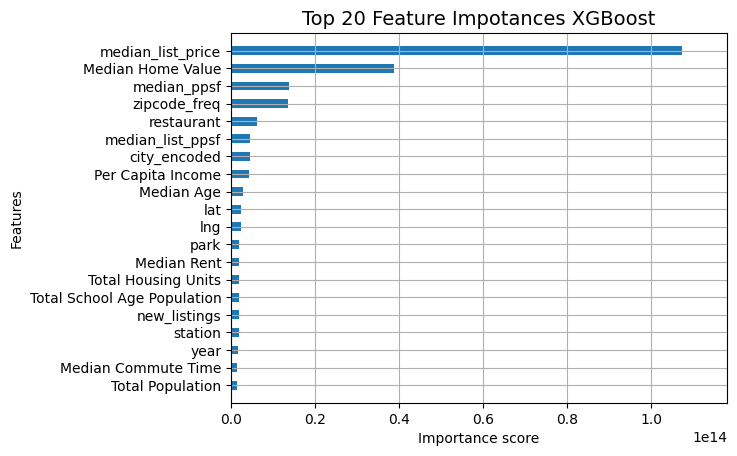

In [4]:
# Plot importances

import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)

plt.title("Top 20 Feature Impotances XGBoost", fontsize=14)
plt.show()